# Homework 7: K-Means Clustering and Image Segmentation
**Name:** Aragya Goyal | **Student ID:** 4541458 | **D value:** 58

In [1]:
# Import packages
import numpy as np
import scipy
import matplotlib.pyplot as plt
import skimage

# Define Globals
D = 58

## Question 1
### Part A: Supervised vs. Unsupervised  
**Text Response:**
1. The K-means algorithm is an unsupervised algorithm because it does not require the output y-labels. So the algorithm does not learn from the relationship between the input features to the output but rather through the patterns within the data itself. Instead of the y-labels, the algorithm uses the distance between the data points to guide the clustering into K groups.
2. Compaered to linear regression, in K-means, the algorithm controls the position of the cluster centroids which are updated in each step of the algorithm. These play the function of theta. And instead of h(x), the K-means algorithm uses the cluster assignment of each of the points which are then used to calculate the SSD. 

### Part B: Convergence and Initialization
**Text Response:**
1. SSD can never increase because in each assignment/update step, the points are assigned to the closest centroid and then a new centroid is calculated as a mean of those assigned points. Since this mean minimizes the sum of squared distances to the assigned points, neither step can produce a higher SSD than before.
2. No, K-Means is not guaranteed to find the globally optimal clustering. This is because the outcome of the algorithm is highly dependent of the centroid starting positions which may cause the algorithm to get stuck in a local minima. This is related to the local minima problem encountered in HW6 because the final loss values depend on the random weight initializations.

### Part C: Choosing K
**Text Response:**
1. We can use a method that looks at how much the SSD changes as the K-value increases. By trying out different values of K, we can likely find a point at which increasing the number of K does not decrease the SSD as much. At this point, we can say that the natural grouping in the data has been found and adding more clusters is just splitting big groups for minimal benefit.

## Question 2: Implementing K-Means
### Part A: Single-Run K-Means

In [2]:
def kmeans_single(X, K, iters, random_seed=D):
    # Set Random Seed
    np.random.seed(random_seed)

    # Get size of X
    m, n = X.shape

    # Initialize K Centers
    indices = np.random.choice(m, K, replace=False)
    means = X[indices]

    # Initialize ssd history
    ssd_history = []

    # Loop through iterations
    for i in range(iters):
        # Compute distances and assign nearest
        dists = scipy.spatial.distance.cdist(X, means, 'euclidean')
        ids = np.argmin(dists, axis=1) + 1

        # Recompute centroids
        for k in range(K):
            mask = (ids == k + 1)
            if np.any(mask):
                means[k] = X[mask].mean(axis=0)

        # Compute ssd
        ssd = 0
        for k in range(K):
            mask = (ids == k + 1)
            if np.any(mask):
                ssd += np.sum((X[mask] - means[k]) ** 2)
        ssd_history.append(ssd)
    
    return ids, means, ssd_history

### Part B: Verification on Toy Data  
**Pre-Computation check:**  
TODO

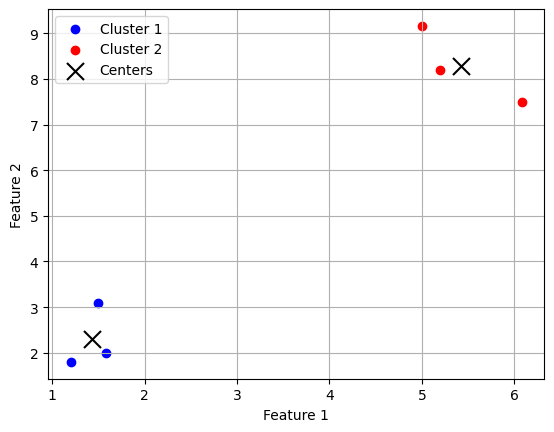

Final SSD: 3.077866666666667


In [3]:
# Define X_toy and other parameters
X_toy = np.array([
    [1.0 + D/100, 2.0],
    [1.5, 2.5 + D/100],
    [1.2, 1.8],
    [5.0, 8.0 + D/50],
    [5.5 + D/100, 7.5],
    [5.2, 8.2]
])
K = 2
iters = 10

# Run K-means
ids, means, ssd_history = kmeans_single(X_toy, K, iters, D)

# Figure output
plt.figure()
colors = ['blue', 'red']
for k in range(1, K+1):
    mask = (ids == k)
    plt.scatter(X_toy[mask, 0], X_toy[mask, 1], c=colors[k-1], label=f'Cluster {k}')
plt.scatter(means[:, 0], means[:, 1], c='black', marker='x', s=150, label='Centers')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

# Report final SSD
print(f"Final SSD: {ssd_history[-1]}")

**Text response:**  
K-means was able to successfully separate the two groups. The final SSD for my D value of 58 was 3.08. This matches my expectations as the value is relatively low since the data has two clear clusters with a large gap in between them. This means that it was easy for K-means clustering to find the correct groups.

### Part C: Multiple Restarts

In [4]:
# Define kmeans_multiple
def kmeans_multiple(X, K, iters, R, base_seed):
    best_ids = None
    best_means = None
    best_ssd = np.inf
    best_ssd_history = None

    # Run kmeans_single R times with incremented seed
    for r in range(R):
        ids, means, ssd_history = kmeans_single(X, K, iters, base_seed + r)
        final_ssd = ssd_history[-1]
        if final_ssd < best_ssd:
            best_ids = ids
            best_means = means
            best_ssd = final_ssd
            best_ssd_history = ssd_history

    return best_ids, best_means, best_ssd, best_ssd_history

# Run on toy data
K = 2
iters = 10
R = 5
ids, means, best_ssd, best_ssd_history = kmeans_multiple(X_toy, K, iters, R, D)
print(f"Best SSD: {best_ssd}")

Best SSD: 3.077866666666667


**Text Response:**  
The best SSD from multiple restarts is 3.08, which is the same as the single-run result from Part B. This is expected because the toy data has two well separated clusters, so any reasonable initialization converges to the same optimal clustering.

### Part D: Convergence Analysis

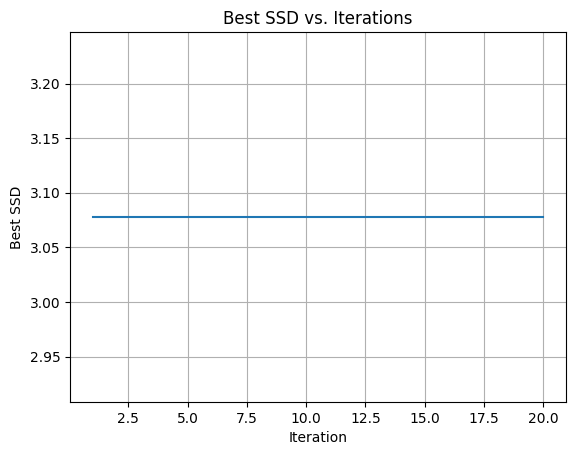

In [5]:
# Run with toy data for 20 iterations
K = 2
iters = 20
R = 5
ids, means, best_ssd, best_ssd_history = kmeans_multiple(X_toy, K, iters, R, D)

# Plot the best ssd history
plt.figure()
plt.plot(range(1, 21), best_ssd_history)
plt.xlabel('Iteration')
plt.ylabel('Best SSD')
plt.title('Best SSD vs. Iterations')
plt.grid(True)
plt.show()

**Text Response:**  
TODO

## Question 3: Image Segmentation
### Part A: Data Prepararation

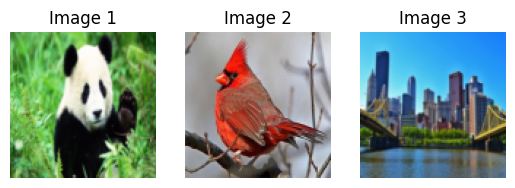

In [6]:
# Load images
image_files = ['input/im1.jpg', 'input/im2.jpg', 'input/im3.png']
images = []
for f in image_files:
    # Load image
    img = plt.imread(f)
    
    # Convert to floating point format - also had to deal with the png image
    if img.max() > 1.0:
        img = img / 255.0
    if img.shape[2] == 4:
        img = img[:, :, :3]

    # Resize to 100 x 100
    img = skimage.transform.resize(img, (100, 100))

    # Append to images
    images.append(img)

# Display the images
fig, axes = plt.subplots(1, len(images))
for i, img in enumerate(images):
    axes[i].imshow(img)
    axes[i].set_title(f'Image {i+1}')
    axes[i].axis('off')
plt.show()

# Reshape into 2D matrix
X_images = []
for img in images:
    X = img.reshape(100*100, 3)
    X_images.append(X)

### Part B: Segmentation - Single Run vs. Multiple Restarts

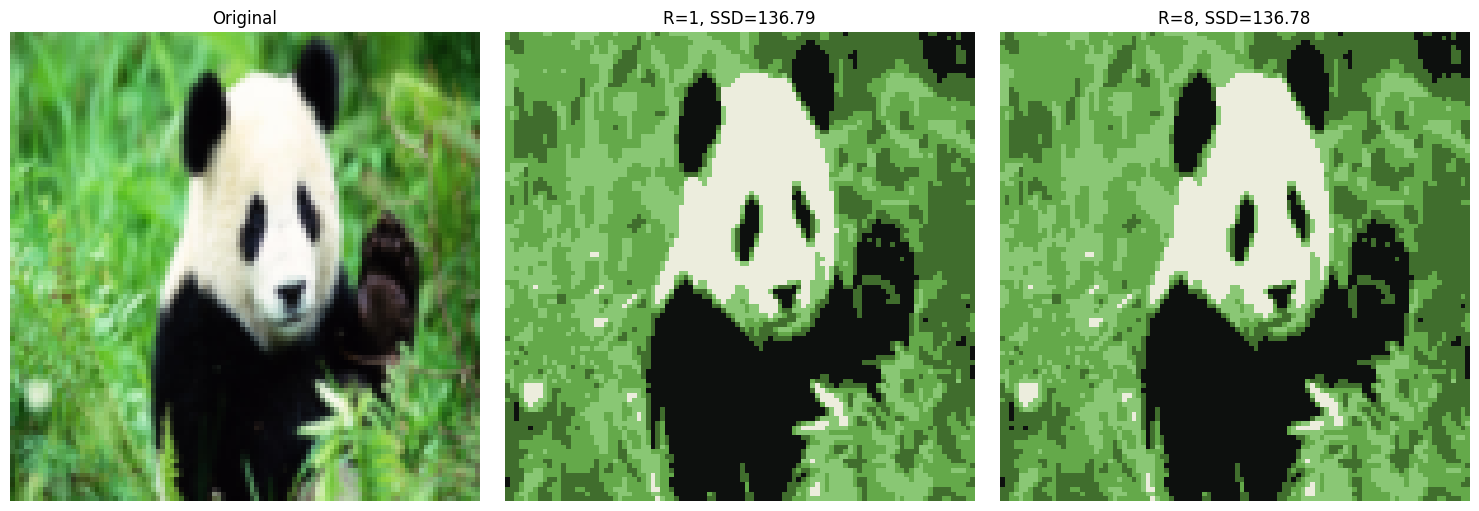

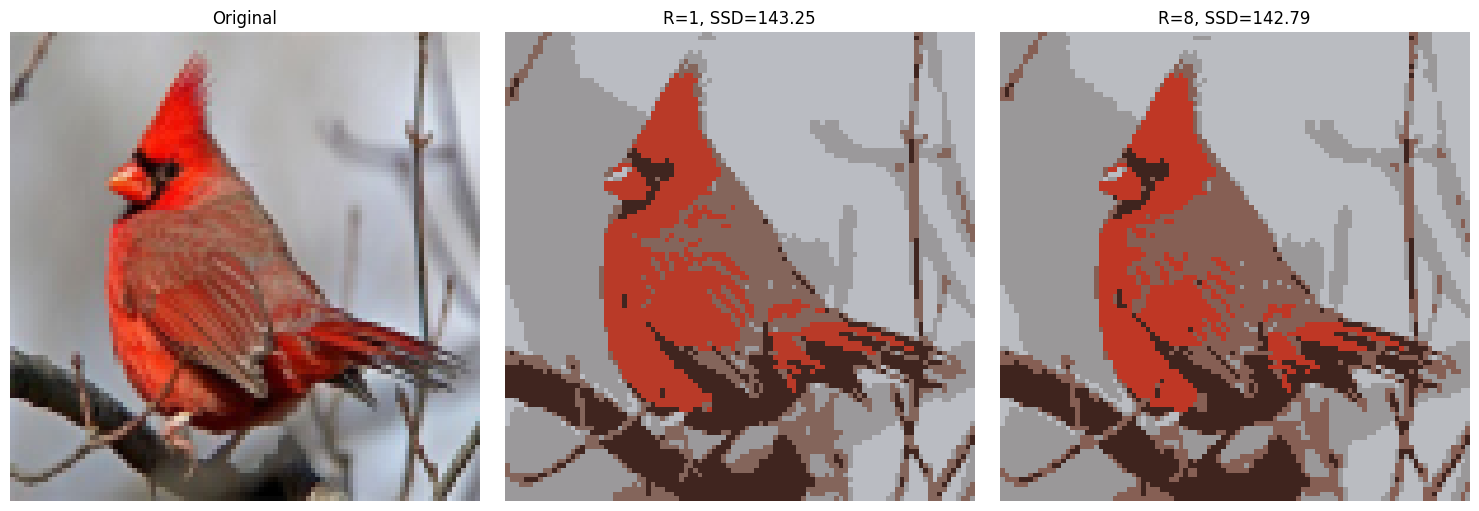

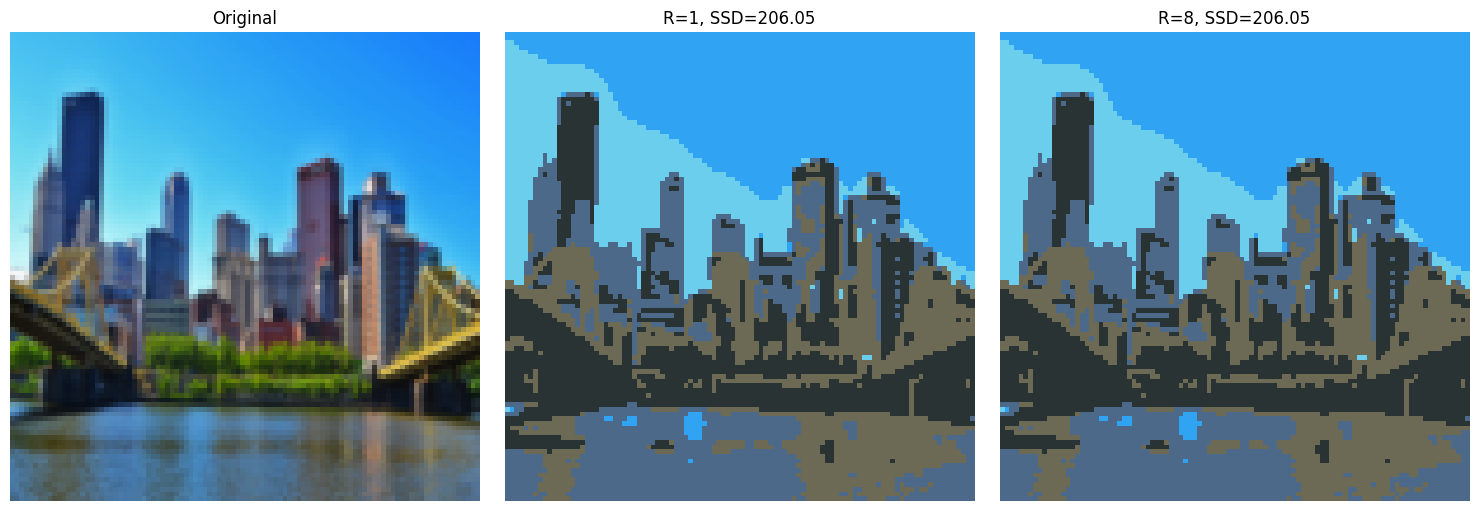

In [7]:
# Calculate personalized parameters
K = 3 + (D % 4)
iters = 15 + (D % 10)
R = 5 + (D % 5)

# Define segmentation helper function
def segment_image(im, K, iters, R, base_seed):
    H, W = im.shape[0], im.shape[1]
    X = im.reshape(H * W, 3)
    ids, means, best_ssd, best_ssd_history = kmeans_multiple(X, K, iters, R, base_seed)
    # Replace each pixel with its cluster's mean color
    segmented = np.zeros_like(X)
    for k in range(1, K + 1):
        mask = (ids == k)
        segmented[mask] = means[k - 1]
    segmented = segmented.reshape(H, W, 3)
    return segmented, best_ssd


for i, img in enumerate(images):
    seg_r1, ssd_r1 = segment_image(img, K, iters, 1, D)
    seg_rR, ssd_rR = segment_image(img, K, iters, R, D)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img)
    axes[0].set_title('Original')
    axes[0].axis('off')
    axes[1].imshow(seg_r1)
    axes[1].set_title(f'R=1, SSD={ssd_r1:.2f}')
    axes[1].axis('off')
    axes[2].imshow(seg_rR)
    axes[2].set_title(f'R={R}, SSD={ssd_rR:.2f}')
    axes[2].axis('off')
    plt.tight_layout()
    plt.show()

**Text Response:**  
1. TODO
2. TODO

### Part C: Effect of K on Segmentation

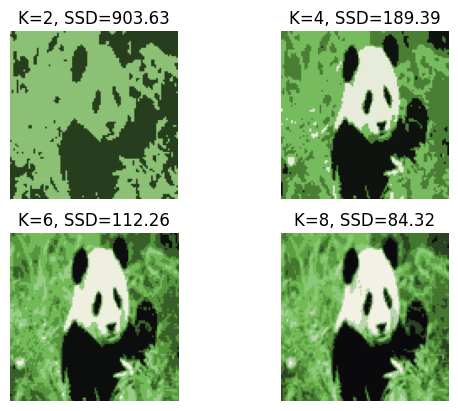

In [15]:
# Choose the first image
img = images[0]

# Define K values array
K_values = [2, 4, 6, 8]

# Loop and segment and plot
fig, axes = plt.subplots(2, 2)
for idx, K in enumerate(K_values):
    row = idx // 2
    col = idx % 2
    seg, ssd = segment_image(img, K, iters, R, D)
    axes[row][col].imshow(seg)
    axes[row][col].set_title(f'K={K}, SSD={ssd:.2f}')
    axes[row][col].axis('off')

plt.show()

**Text Response:**  
1. TODO
2. TODO

### Part D: The Elbow Method - Systematic K Selection

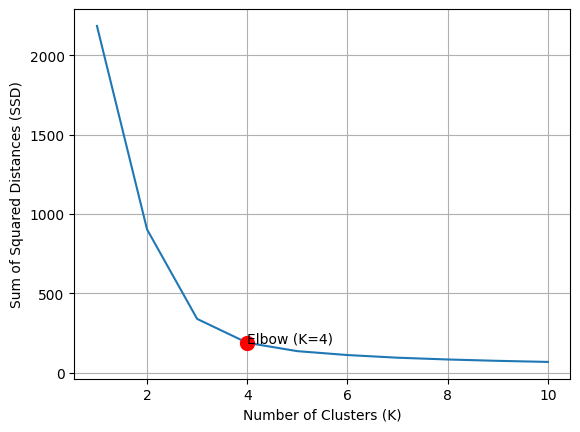

In [22]:
# Initialize array to store best ssd
ssd_values = []

# Loop through K values
for K in range(1,11):
    _, _, best_ssd, _ = kmeans_multiple(img.reshape(100*100, 3), K, iters, R, D)
    ssd_values.append(best_ssd)

# Plot ssd vs k
plt.figure()
plt.plot(range(1,11), ssd_values)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Sum of Squared Distances (SSD)")
plt.grid(True)

# 
plt.plot(4, ssd_values[3], 'ro', markersize=10)
plt.annotate('Elbow (K=4)', xy=(4, ssd_values[3]))
plt.show()


**Text Response:**  
1. TODO
2. TODO
3. TODO

## Question 4: Reflection and Synthesis
### Part A: Results Summary
TODO

### Part B: Effect of Restarts
TODO

### Part C: Limitations of K-Means
TODO

### Part D: K-Means as a Preprocessing Step
TODO

### Part E: Course Arc
TODO